# Reproducible RAG Pipeline

**Pipeline:** chunk → embed → reduce → cluster → visualize

Every function does exactly one thing. Every source of randomness is seeded with `RANDOM_STATE = 42`.

> **Note:** Chunking and clustering are fully deterministic across runs. UMAP dimensionality reduction may produce axially shifted or reflected projections run-to-run despite the fixed seed, due to non-determinism in `pynndescent` (UMAP's nearest-neighbor backend) and floating-point variability.
>
> To get identical 2D and 3D plots across runs, use the cached variants `reduce_to_2d_cached()` and `reduce_to_3d_cached()`, or swap in `reduce_to_2d_pca()` / `reduce_to_3d_pca()` for strictly deterministic reduction.

### Dependencies

Install once before running:

```bash
pip install openai python-dotenv numpy umap-learn scikit-learn matplotlib plotly
```

### Step 1: Import Libraries and API Keys

In [26]:
# ── stdlib ────────────────────────────────────────────────────────────────────
import os
import random
import textwrap

# ── third-party ───────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import gradio as gr
import umap
from matplotlib.patches import Patch
from openai import OpenAI
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from pprint import pprint


### Step 2: Global seed — set once, applied everywhere

In [27]:
RANDOM_STATE: int = 42


def seed_all(seed: int = RANDOM_STATE) -> None:
    """Fix every PRNG that could affect the pipeline.

    Call this once at the very start of your script before anything else.
    Covers: Python's built-in random, NumPy, and (if present) PyTorch.
    """
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True)
    except ImportError:
        pass  # PyTorch not installed — nothing to seed


### Step 3: Environment / API client

In [28]:
def load_api_key() -> str:
    """Load the OpenAI API key from the .env file.

    Returns the key string.
    Raises ValueError if the key is missing.
    """
    load_dotenv()
    key = os.getenv("OPENAI_API_KEY")
    if not key:
        raise ValueError("OPENAI_API_KEY is missing from your .env file.")
    return key


def build_openai_client(api_key: str) -> OpenAI:
    """Construct and return an authenticated OpenAI client."""
    return OpenAI(api_key=api_key)


### Step 4: Chunking helpers  (each does exactly one thing)

In [29]:
def find_natural_boundary(chunk: str, prefix_len: int, min_size: int) -> int | None:
    """Return the best cut index inside *chunk*, or None if none qualifies.

    Priority: paragraph boundary → sentence boundary → word boundary.
    A boundary only qualifies when the resulting chunk would be >= min_size chars.
    The returned index is relative to the start of *chunk*.
    """
    # 1. Paragraph boundary (double newline)
    idx = chunk.rfind("\n\n")
    if idx != -1 and prefix_len + idx + 2 >= min_size:
        return idx + 2

    # 2. Sentence boundary (". ")
    idx = chunk.rfind(". ")
    if idx != -1 and prefix_len + idx + 2 >= min_size:
        return idx + 2

    # 3. Word boundary (single space)
    idx = chunk.rfind(" ")
    if idx != -1 and prefix_len + idx + 1 >= min_size:
        return idx + 1

    return None


def compute_distance_from_text_end(start: int, prefix_len: int, text_len: int) -> int:
    """Return how many characters remain between *start* and the end of the text."""
    return text_len - start - prefix_len


def compute_end(start: int, max_size: int, prefix_len: int, text_len: int) -> int:
    """Return the tentative end position for the current window."""
    return min(start + max_size - prefix_len, text_len)


def apply_boundary(
    start: int,
    end: int,
    text: str,
    prefix: str,
    min_size: int,
) -> tuple[int, bool]:
    """Snap *end* to the nearest natural boundary, if one qualifies.

    Returns (adjusted_end, text_end_reached).
    text_end_reached is True when the window covers the remainder of the text.
    """
    prefix_len = len(prefix)
    remaining = compute_distance_from_text_end(start, prefix_len, len(text))

    if remaining <= (end - start):
        # We've consumed everything — don't try to find a boundary
        return len(text), True

    window = text[start:end]
    cut = find_natural_boundary(window, prefix_len, min_size)
    if cut is not None:
        end = start + cut

    return end, False


def build_chunk(prefix: str, text: str, start: int, end: int) -> str:
    """Concatenate *prefix* with the slice text[start:end]."""
    return prefix + text[start:end]


def handle_small_chunk(
    chunk: str,
    chunks: list[str],
    end: int,
    text_len: int,
    min_size: int,
    max_size: int,
) -> tuple[bool, str | None]:
    """Decide what to do when *chunk* is smaller than *min_size*.

    Options (in priority order):
      1. If we're at the end of the text, append to the last chunk (or emit alone).
      2. If the last emitted chunk can absorb this one without exceeding max_size,
         merge them.
      3. Otherwise carry *chunk* forward as a pending prefix.

    Returns (should_return, pending_chunk).
    should_return=True means the caller should exit immediately.
    """
    if end >= text_len:
        # End of text — absorb into previous chunk or emit standalone
        if chunks and len(chunks[-1]) + len(chunk) <= max_size:
            chunks[-1] += chunk
        else:
            chunks.append(chunk)
        return True, None

    if chunks and len(chunks[-1]) + len(chunk) <= max_size:
        # Previous chunk can absorb this small one
        chunks[-1] += chunk
        return False, None

    # Carry forward to merge with the next chunk
    return False, chunk


def snap_to_word_start(position: int, text: str) -> int:
    """Advance *position* to the start of the next complete word.

    If *position* falls mid-word, move forward until we hit a space (or end
    of text), then skip the space itself.
    """
    if position >= len(text):
        return len(text)

    # Already at a word start (space before, or position 0)
    if position == 0 or text[position - 1] == " ":
        return position

    # Mid-word — scan forward to the next space
    space_idx = text.find(" ", position)
    if space_idx == -1:
        return len(text)  # last word — jump to end

    return space_idx + 1  # skip the space


def advance_start(start: int, end: int, overlap: int, text: str) -> int:
    """Compute the next start position, snapped to a word boundary.

    Moves to end - overlap, but never backward. If the overlap region is
    already behind us, jumps directly to end.
    """
    next_start = end - overlap
    if next_start <= start:
        next_start = end
    return snap_to_word_start(next_start, text)


### Step 5: Chunking entry point

In [30]:
def chunk_text(
    text: str,
    max_size: int = 1000,
    overlap: int = 50,
    min_size: int = 500,
) -> list[str]:
    """Split *text* into overlapping chunks that respect natural boundaries.

    Chunking is fully deterministic — no randomness is involved — so
    random_state does not affect this step. Reproducibility here comes from
    the algorithm itself.

    Args:
        text:     The raw input string to chunk.
        max_size: Maximum chunk length in characters.
        overlap:  Number of characters from the previous chunk to repeat at
                  the start of the next one (context window overlap).
        min_size: Chunks shorter than this are merged with a neighbour.

    Returns:
        A list of non-empty text strings.
    """
    chunks: list[str] = []
    start = 0
    pending: str | None = None

    while start < len(text):
        prefix = pending if pending is not None else ""
        pending = None

        end = compute_end(start, max_size, len(prefix), len(text))
        end, text_end_reached = apply_boundary(start, end, text, prefix, min_size)

        new_chunk = build_chunk(prefix, text, start, end)

        if text_end_reached:
            chunks.append(new_chunk)
            return chunks

        if len(new_chunk) < min_size:
            should_return, pending = handle_small_chunk(
                new_chunk, chunks, end, len(text), min_size, max_size
            )
            if should_return:
                return chunks
        else:
            chunks.append(new_chunk)

        start = advance_start(start, end, overlap, text)

    return chunks


### Step 6: Embeddings

In [31]:
def embed_chunks(
    chunks: list[str],
    client: OpenAI,
    model: str = "text-embedding-3-small",
) -> list[list[float]]:
    """Call the OpenAI Embeddings API and return one vector per chunk.

    The embedding model itself is deterministic for the same input — no
    random_state needed here — but using a fixed model string ensures
    consistent vector dimensionality across runs.

    Args:
        chunks: List of text strings to embed.
        client: An authenticated OpenAI client.
        model:  The embedding model to use.

    Returns:
        A list of float vectors, one per chunk, in the same order.
    """
    response = client.embeddings.create(input=chunks, model=model)
    return [item.embedding for item in response.data]


def embeddings_to_array(embeddings: list[list[float]]) -> np.ndarray:
    """Convert a list of embedding vectors to a 2-D NumPy array (n_chunks × dim)."""
    return np.array(embeddings, dtype=np.float32)


### Step 7: Dimensionality reduction  (random_state applied)

In [32]:
def reduce_to_2d(
    embedding_matrix: np.ndarray,
    seed: int = RANDOM_STATE,
) -> np.ndarray:
    """Project *embedding_matrix* to 2D with UMAP.

    random_state + n_jobs=1 together guarantee a reproducible layout:
      - random_state seeds UMAP's internal PRNG for initialisation.
      - n_jobs=1 disables parallelism whose non-deterministic scheduling
        would otherwise cause slight numerical differences run-to-run.

    Returns an (n_chunks × 2) array.
    """
    reducer = umap.UMAP(n_components=2, random_state=seed, n_jobs=1)
    return reducer.fit_transform(embedding_matrix)


def reduce_to_3d(
    embedding_matrix: np.ndarray,
    seed: int = RANDOM_STATE,
) -> np.ndarray:
    """Project *embedding_matrix* to 3D with UMAP.

    Same reproducibility contract as reduce_to_2d.
    Returns an (n_chunks × 3) array.
    """
    reducer = umap.UMAP(n_components=3, random_state=seed, n_jobs=1)
    return reducer.fit_transform(embedding_matrix)


### Step 8: Clustering (random_state applied)

In [33]:
def cluster_embeddings(
    reduced: np.ndarray,
    n_clusters: int = 2,
    seed: int = RANDOM_STATE,
) -> np.ndarray:
    """Assign cluster labels to the reduced embeddings via KMeans.

    random_state seeds centroid initialisation so the same data always
    yields the same cluster assignments.
    n_init=10 runs 10 independent initialisations and picks the best,
    improving stability without sacrificing reproducibility.

    Returns a 1-D integer array of labels (length == n_chunks).
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    return kmeans.fit_predict(reduced)


### Step 9: Cluster grouping

In [34]:
def group_chunks_by_cluster(
    chunks: list[str],
    labels: np.ndarray,
) -> dict[int, list[str]]:
    """Return a mapping {cluster_id: [chunk, ...]} for every label value."""
    groups: dict[int, list[str]] = {}
    for chunk, label in zip(chunks, labels):
        groups.setdefault(int(label), []).append(chunk)
    return groups


### Step 10: Cluster description via LLM

In [35]:
def describe_cluster(
    cluster_chunks: list[str],
    cluster_id: int,
    client: OpenAI,
    model: str = "gpt-4o-mini",
    max_chunks: int = 10,
) -> tuple[int, str]:
    """Ask the LLM to summarise the unifying theme of a cluster's chunks.

    Args:
        cluster_chunks: Text chunks belonging to this cluster.
        cluster_id:     Integer label for the cluster.
        client:         Authenticated OpenAI client.
        model:          Chat model to use for summarisation.
        max_chunks:     Cap on how many chunks to include (token budget guard).

    Returns:
        (cluster_id, description_string)
    """
    combined = "\n\n".join(cluster_chunks[:max_chunks])
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a helpful assistant that analyses and summarises "
                    "groups of text chunks."
                ),
            },
            {
                "role": "user",
                "content": (
                    "Here are text chunks grouped by semantic similarity:\n\n"
                    f"{combined}\n\n"
                    "In 2–3 sentences, describe what topic or theme unites them."
                ),
            },
        ],
    )
    description = response.choices[0].message.content
    return cluster_id, description


### Step 11: 2-D visualisation

In [36]:
CLUSTER_COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]


def build_cluster_color_map(
    labels: np.ndarray,
    colors: list[str] = CLUSTER_COLORS,
) -> list[str]:
    """Return a per-point color list based on cluster *labels*."""
    return [colors[label % len(colors)] for label in labels]


def plot_2d_clusters(
    reduced: np.ndarray,
    labels: np.ndarray,
    title: str = "UMAP Projection of Chunk Embeddings",
) -> None:
    """Render a 2-D scatter plot of the reduced embeddings, colored by cluster.

    Each point is annotated with its chunk index.
    Shows the plot immediately (blocking call).
    """
    cluster_colors = build_cluster_color_map(labels)
    n_clusters = len(set(labels))
    colors = CLUSTER_COLORS[:n_clusters]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        reduced[:, 0], reduced[:, 1],
        c=cluster_colors, alpha=0.7, s=50,
    )

    for i, (x, y) in enumerate(reduced):
        plt.annotate(
            str(i), (x, y),
            textcoords="offset points", xytext=(5, 5),
            fontsize=7, alpha=0.8,
        )

    legend_elements = [
        Patch(facecolor=colors[k], label=f"Cluster {k}")
        for k in range(n_clusters)
    ]
    plt.legend(handles=legend_elements, loc="best")
    plt.title(title)
    plt.tight_layout()
    plt.show()


### Step 12: 3-D visualisation

In [37]:
def plot_3d_clusters(
    reduced: np.ndarray,
    labels: np.ndarray,
    title: str = "UMAP 3D Projection of Chunk Embeddings",
) -> None:
    """Render an interactive 3-D Plotly scatter of the reduced embeddings.

    One trace per cluster so the legend toggles clusters on/off.
    Shows the plot immediately in the default browser.
    """
    n_clusters = len(set(labels))
    colors = CLUSTER_COLORS[:n_clusters]

    fig = go.Figure()

    for cluster_id, color in enumerate(colors):
        mask = labels == cluster_id
        idx = np.where(mask)[0]

        fig.add_trace(go.Scatter3d(
            x=reduced[mask, 0],
            y=reduced[mask, 1],
            z=reduced[mask, 2],
            mode="markers+text",
            marker=dict(size=5, color=color, opacity=0.75),
            text=[str(i) for i in idx],
            textposition="top center",
            textfont=dict(size=8),
            name=f"Cluster {cluster_id}",
        ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="UMAP 1",
            yaxis_title="UMAP 2",
            zaxis_title="UMAP 3",
        ),
        legend=dict(itemsizing="constant"),
        margin=dict(l=0, r=0, b=0, t=40),
    )

    fig.show()


### Step 13: Printing helpers

In [38]:
def print_chunks(chunks: list[str]) -> None:
    """Print every chunk with its index, character count, and full text."""
    print(f"Total chunks : {len(chunks)}")
    print(f"Chunk sizes  : {[len(c) for c in chunks]}\n")
    print("=" * 70)
    for i, chunk in enumerate(chunks, 1):
        print(f"\n{'─' * 70}")
        print(f"CHUNK {i:02d}  ({len(chunk)} chars)")
        print(f"{'─' * 70}")
        print(chunk)


def print_cluster_description(cluster_id: int, description: str, width: int = 88) -> None:
    """Pretty-print a single cluster's LLM-generated description."""
    filled = textwrap.fill(description, width=width) if isinstance(description, str) else (
        f"Warning: description is not a string (got {type(description).__name__})"
    )
    print(f"Cluster {cluster_id} description:\n{filled}\n")


### Step 14: Pipeline orchestrator

In [39]:
def run_pipeline(document: str) -> None:
    """Run the full reproducible RAG pipeline on *document*.

    Steps
    -----
    1.  Seed every PRNG (Pseudo-Random Number Generator).
    2.  Authenticate with OpenAI.
    3.  Chunk the document.
    4.  Embed the chunks.
    5.  Reduce to 2-D and 3-D.
    6.  Cluster both reduced representations.
    7.  Describe each cluster via the LLM.
    8.  Visualise in 2-D (matplotlib) and 3-D (Plotly).
    """
    # ── 1. Reproducibility ───────────────────────────────────────────────────
    seed_all(RANDOM_STATE)

    # ── 2. Auth ──────────────────────────────────────────────────────────────
    api_key = load_api_key()
    client = build_openai_client(api_key)

    # ── 3. Chunk ──────────────────────────────────────────────────────────────
    chunks = chunk_text(document, max_size=1000, overlap=50, min_size=500)
    print_chunks(chunks)

    # ── 4. Embed ──────────────────────────────────────────────────────────────
    raw_embeddings = embed_chunks(chunks, client)
    embedding_matrix = embeddings_to_array(raw_embeddings)
    print(f"\nGenerated {len(raw_embeddings)} embeddings "
          f"({len(raw_embeddings[0])} dimensions each)\n")

    # ── 5 & 6. Reduce + cluster (2-D) ────────────────────────────────────────
    reduced_2d = reduce_to_2d(embedding_matrix, seed=RANDOM_STATE)
    labels_2d = cluster_embeddings(reduced_2d, n_clusters=2, seed=RANDOM_STATE)

    # ── 7. Describe clusters ──────────────────────────────────────────────────
    groups = group_chunks_by_cluster(chunks, labels_2d)
    for cid, cchunks in groups.items():
        _, description = describe_cluster(cchunks, cid, client)
        print_cluster_description(cid, description)

    # ── 8a. 2-D plot ──────────────────────────────────────────────────────────
    plot_2d_clusters(reduced_2d, labels_2d)

    # ── 5 & 6. Reduce + cluster (3-D) ────────────────────────────────────────
    reduced_3d = reduce_to_3d(embedding_matrix, seed=RANDOM_STATE)
    labels_3d = cluster_embeddings(reduced_3d, n_clusters=2, seed=RANDOM_STATE)

    # ── 8b. 3-D plot ──────────────────────────────────────────────────────────
    plot_3d_clusters(reduced_3d, labels_3d)

    return chunks, raw_embeddings, embedding_matrix


### Step 15: Entry point

Total chunks : 16
Chunk sizes  : [697, 974, 879, 995, 852, 787, 992, 806, 927, 736, 973, 834, 673, 982, 883, 229]


──────────────────────────────────────────────────────────────────────
CHUNK 01  (697 chars)
──────────────────────────────────────────────────────────────────────

NETFLIX CULTURE MEMO:
The Best Work of Our Lives
CULTURE MEMO
At Netflix, we aspire to entertain the world, thrilling audiences everywhere. To do that, we’ve
developed an unusual company culture focused on excellence, and creating an environment
where talented people can thrive — lifting ourselves, each other and our audiences higher and
higher. This document is about that culture, which is based on four core principles:
● The Dream Team: We aim only to have high performers at Netflix — people who are
great at what they do, and even better at working together.
● People over Process: You get better outcomes when employees have the information
and freedom to make decisions for themselves. 

─────────────────────

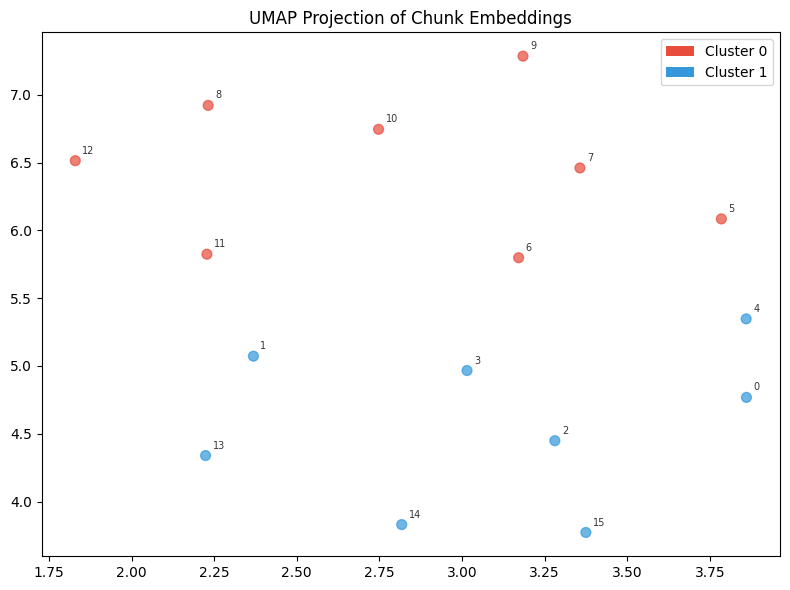

In [40]:
# Document is slightly modified from original. Original text is below for reference.

if __name__ == "__main__":
    DOCUMENT = """
NETFLIX CULTURE MEMO:
The Best Work of Our Lives
CULTURE MEMO
At Netflix, we aspire to entertain the world, thrilling audiences everywhere. To do that, we’ve
developed an unusual company culture focused on excellence, and creating an environment
where talented people can thrive — lifting ourselves, each other and our audiences higher and
higher. This document is about that culture, which is based on four core principles:
● The Dream Team: We aim only to have high performers at Netflix — people who are
great at what they do, and even better at working together.
● People over Process: You get better outcomes when employees have the information
and freedom to make decisions for themselves. We hire unusually responsible people
who thrive on this openness and freedom.
● Uncomfortably Exciting: To entertain the world, we need to be bold and ambitious.
That means embracing the thrill of what’s next — even when it’s uncomfortable.
● Great and Always Better: We often say Netflix sucks today compared to where we can
be tomorrow. We need the self-awareness to understand what should be better, and
the discipline and resilience to get there.
While we don’t always live up to these principles, most people who join Netflix are pleasantly
surprised by how great their colleagues are and the way we empower people at every level.
As our business grows and evolves, our culture (and this document) will, too. What won’t
change is our focus on excellence, and our determination to ensure that Netflix remains a
place where great people can do the best work of their lives. If this sounds exciting, you’ll
probably love it here. But Netflix is not for everyone, so please read on.
THE DREAM TEAM
We believe that what makes a fantastic workplace isn’t a great office or free meals and
massages — although we have some nice perks. It’s the people. Imagine working alongside
stunning colleagues who are great at what they do, and even better at working together. It’s
why we model ourselves on a professional sports team, not a family. Families are about
unconditional love. They can also be dysfunctional, as anyone who’s watched Ozark or
Wednesday knows. Professional sports teams, on the other hand, focus on performance and
picking the right person for every position, even when that means swapping out someone
they love for a better player.
While every member of our Dream Team has different skills, we look for common strengths
that make us better together. These are the values we value:
● Selflessness — you are humble when searching for the best ideas; you seek what’s
best for Netflix, not yourself or your team; you take time to help others succeed.
● Judgment — you look beyond short term fixes in favor of long term solutions; you
make wise decisions despite ambiguity; you use data to inform your intuition.
● Candor — you willingly receive and give feedback; you are open about what’s working
and what needs to improve; you admit mistakes openly and share learnings widely.
● Creativity — you welcome new ideas; you are passionate and persistent in pursuit of
more innovative solutions; you value artistic expression.
● Courage — you are vulnerable in search for the truth; you are willing to risk failure, or
challenge the status quo, in the pursuit of excellence.
● Inclusion — you recognize your biases and work to counteract them; you try to ensure
everyone at Netflix can do their best work, whatever their culture, identity or
background.
● Curiosity — you learn rapidly and eagerly; you are more interested in other people’s
ideas than your own; you’re humble about what you don’t yet know.
● Resilience — you quickly adapt to changing circumstances; you make tough decisions
without agonizing or long delay; you embrace a hard challenge.
It’s easy to talk about values and harder to live by them. We all work hard to keep each other
accountable for upholding these standards, especially our leaders, because excellence and
honesty go hand in hand. It’s why we invest in strong professional relationships that build trust
and help people assume good intent. This, in turn, enables us to practice extraordinary
candor — ensuring constructive feedback is part of our everyday work (like brushing your
teeth). It takes courage and vulnerability to ask someone how you could do better, or to seek
alternative opinions about the best way forward, and integrity only to say things about a
colleague that you’re willing to share with them directly. This is especially true when you’re
giving feedback to someone more senior or from a different background, or if you come from
a culture or company where deference is the norm. But extraordinary candor helps us improve
faster as individuals and a company.
Since a high performer in any role is many times more effective than the average employee,
our Dream Team is driven by performance — not seniority, tenure or unconditional loyalty. It’s
also why we focus on maintaining a high performance culture. To recruit and retain stunning
colleagues, we pay personal top of market for the role and location — a judgment about what
that person could make in a similar role at another company, and what we would pay to keep
or replace them. We expect leaders to be strong developers of talent. And to ensure they have
the right player at every position, we ask them to apply what we call the “keeper test” —
asking “if X wanted to leave, would I fight to keep them?” Or “knowing everything I know
today, would I hire X again?” If the answer is no, we believe it’s fairer to everyone to part ways
quickly.
The “keeper test” name came from our co-founder, Reed Hastings, who remembers catching a fish as a
child and his dad saying, “That’s a keeper, Reed!”
In the abstract, the keeper test can sound scary. In reality, we encourage everyone to speak to
their managers about what’s going well and what’s not on a regular basis. This helps avoid
surprises. Managers also evaluate team members on their whole record, rather than focusing
on the mistakes or bets that didn’t pay off. On the Dream Team, you need people who
challenge the status quo and try new things. So we stick with employees through short-term
bumps.
No matter how brilliant someone may be, there’s no place in our Dream Team for people who
don’t treat their colleagues with decency and respect. When you have talented people who
work well together — trusting each other’s intentions and respecting their differences — it
makes everyone more successful.
PEOPLE OVER PROCESS
Many of us have worked at companies where decisions were made top down, there was little
transparency and it felt hard to make a difference — or even get basic things done. At Netflix,
we aim to inspire and empower more than just manage because people can have a greater
impact when they’re free to make decisions about their own work.
As part of this, we strive to develop good decision-making muscles at every level of the
company, priding ourselves on how few, not how many, decisions senior leaders make. We
expect managers to practice context not control — giving their teams the context and clarity
needed to make good decisions instead of trying to control everything themselves. We also
help employees learn by sharing a lot of information internally, including through memos
where they can comment and ask questions. It takes an unusually responsible person to
thrive on this level of freedom — someone who’s self-motivated, self-aware and
self-disciplined, who doesn’t wait to be told what to do and picks up the trash like they would
at home. That said, context not control should not be confused with hands-off management.
Managers need to be involved in the work being done around them, and actively coach their
teams. They may also have to step in when someone is about to make a decision that is
unethical or could materially harm Netflix, during a crisis or if a new team member lacks the
full context.
We avoid decision-making by committee, which tends to slow companies down and
undermine accountability. For every significant decision, we identify an informed captain
who’s responsible for making a judgment call on the right way ahead. Then different teams,
each led by their own informed captain, implement the decision. This highly aligned and
loosely coupled approach gives teams the freedom to move quickly and operate
independently, while ensuring responsibility for the outcome.
We’ve learned that the best ideas can come from anywhere, which is why we expect informed
captains to seek out different opinions and listen to people at every level. We call this farming
for dissent. Of course, not all opinions are created equal — and with 10,000-plus employees,
it’s impractical for everyone to weigh in on most decisions (this memo being an exception). So
on an important creative decision, for example, the opinion of someone working in TV, film or
games will carry more weight than an engineer, and vice versa when it comes to our product
or technology. After a decision is made, we expect everyone, including the people who argued
for a different approach, to disagree and commit. This helps ensure the outcome is as
successful as possible. Afterwards, when the impact is clear, the informed captain should
reflect on their choices — what worked and what didn’t — so everyone can learn how to do
better next time.
Launching a game, TV show or film, running a marketing campaign, managing compensation
and closing a quarter all take process. And companies need strict rules against things like
harassment, marginalizing colleagues, leaking company information, or insider trading. But we
work hard to keep rules at Netflix to a minimum and ensure any process is good (simple,
efficient, impactful). Our vacation policy, for example, is two words: “Take vacation.” And our
expenses policy is just five words: “Act in Netflix’s best interests.” This (almost) no rules rule
gives employees the freedom to exercise their judgment. It also prevents the process creep
that typically happens when companies grow and try to dummy proof their organizations —
stifling creativity and making it harder for businesses to adapt.
You might think that this kind of freedom would lead to chaos. In reality, while we’ve had our
fair share of failures — and a few people have taken advantage of our culture in bad ways —
our emphasis on individual autonomy has created an extremely successful business, with
many opportunities for employees to develop and grow. In entertainment and technology, our
biggest threat is a lack of creativity, adaptability and innovation. It’s why trying to minimize
rules and processes (rather than errors) — while giving people the freedom to use their own
judgment and learn from their mistakes — is a far superior recipe for long-term success.
UNCOMFORTABLY EXCITING
Netflix is programming for well over half a billion2 people globally — something no other
entertainment company has ever done before. Success requires us to be bold and ambitious,
to think differently, experiment and adapt (often quickly). This is true whether we’re designing
a new product feature, working to improve our recommendations, developing a marketing
campaign or creating a TV show or game. Many people will be happier at companies that are
more stable or take fewer risks. Netflix works best if you value experimentation, enjoy the
uncomfortable excitement of a new or challenging project and have the resilience to thrive in
this environment.
ARTISTIC EXPRESSION
Representation matters. Our members come from many different backgrounds and cultures,
and they want to see a wide variety of stories and people on screen. This diversity is
wonderful and it can create real tension since we all have such different views about what’s
acceptable — and what’s harmful — on TV. While every show, film or game is different, we
approach them with the same set of principles: we support the artistic expression of the
creators we choose to work with; we program for a wide variety of audiences, cultures and
tastes; and we provide ratings, content advisories and parental controls in multiple languages
to help members choose what to watch or play. As employees, we support these principles,
even if some stories run counter to our personal values. And we understand that, depending
2 As of Q1 2024 ~260 million households subscribe to Netflix. Assuming ~2 people per household —
which is conservative — that means our audience is over 500M.
© 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version
"""
    
    chunks, raw_embeddings, embedding_matrix = run_pipeline(DOCUMENT)


In [41]:
# Original document downloaded from Netflix site
document2 = """
    NETFLIX CULTURE MEMO:
    The Best Work of Our Lives 
    CULTURE MEMO 
    At Netflix, we aspire to entertain the world, thrilling audiences everywhere. To do that, we’ve 
    developed an unusual company culture focused on excellence, and creating an environment 
    where talented people can thrive — lifting ourselves, each other and our audiences higher and 
    higher. This document is about that culture, which is based on four core principles: 
    ● The Dream Team: We aim only to have high performers at Netflix — people who are 
    great at what they do, and even better at working together. 
    ● People over Process: You get better outcomes when employees have the information 
    and freedom to make decisions for themselves. We hire unusually responsible people 
    who thrive on this openness and freedom.  
    ● Uncomfortably Exciting: To entertain the world, we need to be bold and ambitious. 
    That means embracing the thrill of what’s next — even when it’s uncomfortable.  
    ● Great and Always Better: We often say Netflix sucks today compared to where we can 
    be tomorrow. We need the self-awareness to understand what should be better, and 
    the discipline and resilience to get there.     
    While we don’t always live up to these principles, most people who join Netflix are pleasantly 
    surprised by how great their colleagues are and the way we empower people at every level. 
    As our business grows and evolves, our culture (and this document) will, too. What won’t 
    change is our focus on excellence, and our determination to ensure that Netflix remains a 
    place where great people can do the best work of their lives. If this sounds exciting, you’ll 
    probably love it here. But Netflix is not for everyone, so please read on.  
    THE DREAM TEAM 
    We believe that what makes a fantastic workplace isn’t a great office or free meals and 
    massages — although we have some nice perks. It’s the people. Imagine working alongside 
    stunning colleagues who are great at what they do, and even better at working together. It’s 
    why we model ourselves on a professional sports team, not a family. Families are about 
    unconditional love. They can also be dysfunctional, as anyone who’s watched Ozark or 
    Wednesday knows. Professional sports teams, on the other hand, focus on performance and 
    picking the right person for every position, even when that means swapping out someone 
    they love for a better player. 
    © 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version 
    While every member of our Dream Team has different skills, we look for common strengths 
    that make us better together. These are the values we value: 
    ● Selflessness — you are humble when searching for the best ideas; you seek what’s 
    best for Netflix, not yourself or your team; you take time to help others succeed.  
    ● Judgment — you look beyond short term fixes in favor of long term solutions; you 
    make wise decisions despite ambiguity; you use data to inform your intuition. 
    ● Candor — you willingly receive and give feedback; you are open about what’s working 
    and what needs to improve; you admit mistakes openly and share learnings widely.  
    ● Creativity — you welcome new ideas; you are passionate and persistent in pursuit of 
    more innovative solutions; you value artistic expression. 
    ● Courage — you are vulnerable in search for the truth; you are willing to risk failure, or 
    challenge the status quo, in the pursuit of excellence.  
    ●  Inclusion — you recognize your biases and work to counteract them; you try to ensure 
    everyone at Netflix can do their best work, whatever their culture, identity or 
    background.  
    ● Curiosity — you learn rapidly and eagerly; you are more interested in other people’s 
    ideas than your own; you’re humble about what you don’t yet know. 
    ● Resilience — you quickly adapt to changing circumstances; you make tough decisions 
    without agonizing or long delay; you embrace a hard challenge. 
    It’s easy to talk about values and harder to live by them. We all work hard to keep each other 
    accountable for upholding these standards, especially our leaders, because excellence and 
    honesty go hand in hand. It’s why we invest in strong professional relationships that build trust 
    and help people assume good intent. This, in turn, enables us to practice extraordinary 
    candor — ensuring constructive feedback is part of our everyday work (like brushing your 
    teeth). It takes courage and vulnerability to ask someone how you could do better, or to seek 
    alternative opinions about the best way forward, and integrity only to say things about a 
    colleague that you’re willing to share with them directly. This is especially true when you’re 
    giving feedback to someone more senior or from a different background, or if you come from 
    a culture or company where deference is the norm. But extraordinary candor helps us improve 
    faster as individuals and a company.  
    Since a high performer in any role is many times more effective than the average employee, 
    our Dream Team is driven by performance — not seniority, tenure or unconditional loyalty. It’s 
    also why we focus on maintaining a high performance culture. To recruit and retain stunning 
    colleagues, we pay personal top of market for the role and location — a judgment about what 
    that person could make in a similar role at another company, and what we would pay to keep 
    or replace them. We expect leaders to be strong developers of talent. And to ensure they have 
    the right player at every position, we ask them to apply what we call the “keeper test”1 — 
    asking “if X wanted to leave, would I fight to keep them?” Or “knowing everything I know 
    today, would I hire X again?” If the answer is no, we believe it’s fairer to everyone to part ways 
    quickly.  
    1The “keeper test” name came from our co-founder, Reed Hastings, who remembers catching a fish as a 
    child and his dad saying, “That’s a keeper, Reed!” 
    © 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version 
    In the abstract, the keeper test can sound scary. In reality, we encourage everyone to speak to 
    their managers about what’s going well and what’s not on a regular basis. This helps avoid 
    surprises. Managers also evaluate team members on their whole record, rather than focusing 
    on the mistakes or bets that didn’t pay off. On the Dream Team, you need people who 
    challenge the status quo and try new things. So we stick with employees through short-term 
    bumps.   
    No matter how brilliant someone may be, there’s no place in our Dream Team for people who 
    don’t treat their colleagues with decency and respect. When you have talented people who 
    work well together — trusting each other’s intentions and respecting their differences — it 
    makes everyone more successful.  
    PEOPLE OVER PROCESS 
    Many of us have worked at companies where decisions were made top down, there was little 
    transparency and it felt hard to make a difference — or even get basic things done. At Netflix, 
    we aim to inspire and empower more than just manage because people can have a greater 
    impact when they’re free to make decisions about their own work.  
    As part of this, we strive to develop good decision-making muscles at every level of the 
    company, priding ourselves on how few, not how many, decisions senior leaders make. We 
    expect managers to practice context not control — giving their teams the context and clarity 
    needed to make good decisions instead of trying to control everything themselves. We also 
    help employees learn by sharing a lot of information internally, including through memos 
    where they can comment and ask questions. It takes an unusually responsible person to 
    thrive on this level of freedom — someone who’s self-motivated, self-aware and 
    self-disciplined, who doesn’t wait to be told what to do and picks up the trash like they would 
    at home. That said, context not control should not be confused with hands-off management. 
    Managers need to be involved in the work being done around them, and actively coach their 
    teams. They may also have to step in when someone is about to make a decision that is 
    unethical or could materially harm Netflix, during a crisis or if a new team member lacks the 
    full context.  
    We avoid decision-making by committee, which tends to slow companies down and 
    undermine accountability. For every significant decision, we identify an informed captain 
    who’s responsible for making a judgment call on the right way ahead. Then different teams, 
    each led by their own informed captain, implement the decision. This highly aligned and 
    loosely coupled approach gives teams the freedom to move quickly and operate 
    independently, while ensuring responsibility for the outcome.  
    We’ve learned that the best ideas can come from anywhere, which is why we expect informed 
    captains to seek out different opinions and listen to people at every level. We call this farming 
    for dissent. Of course, not all opinions are created equal — and with 10,000-plus employees, 
    it’s impractical for everyone to weigh in on most decisions (this memo being an exception). So 
    on an important creative decision, for example, the opinion of someone working in TV, film or 
    games will carry more weight than an engineer, and vice versa when it comes to our product 
    or technology. After a decision is made, we expect everyone, including the people who argued 
    © 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version 
    for a different approach, to disagree and commit. This helps ensure the outcome is as 
    successful as possible. Afterwards, when the impact is clear, the informed captain should 
    reflect on their choices — what worked and what didn’t — so everyone can learn how to do 
    better next time.  
    Launching a game, TV show or film, running a marketing campaign, managing compensation 
    and closing a quarter all take process. And companies need strict rules against things like 
    harassment, marginalizing colleagues, leaking company information, or insider trading. But we 
    work hard to keep rules at Netflix to a minimum and ensure any process is good (simple, 
    efficient, impactful). Our vacation policy, for example, is two words: “Take vacation.” And our 
    expenses policy is just five words: “Act in Netflix’s best interests.” This (almost) no rules rule 
    gives employees the freedom to exercise their judgment. It also prevents the process creep 
    that typically happens when companies grow and try to dummy proof their organizations — 
    stifling creativity and making it harder for businesses to adapt.  
    You might think that this kind of freedom would lead to chaos. In reality, while we’ve had our 
    fair share of failures — and a few people have taken advantage of our culture in bad ways — 
    our emphasis on individual autonomy has created an extremely successful business, with 
    many opportunities for employees to develop and grow. In entertainment and technology, our 
    biggest threat is a lack of creativity, adaptability and innovation. It’s why trying to minimize 
    rules and processes (rather than errors) — while giving people the freedom to use their own 
    judgment and learn from their mistakes — is a far superior recipe for long-term success.  
    UNCOMFORTABLY EXCITING 
    Netflix is programming for well over half a billion2 people globally — something no other 
    entertainment company has ever done before. Success requires us to be bold and ambitious, 
    to think differently, experiment and adapt (often quickly). This is true whether we’re designing 
    a new product feature, working to improve our recommendations, developing a marketing 
    campaign or creating a TV show or game. Many people will be happier at companies that are 
    more stable or take fewer risks. Netflix works best if you value experimentation, enjoy the 
    uncomfortable excitement of a new or challenging project and have the resilience to thrive in 
    this environment. 
    ARTISTIC EXPRESSION 
    Representation matters. Our members come from many different backgrounds and cultures, 
    and they want to see a wide variety of stories and people on screen. This diversity is 
    wonderful and it can create real tension since we all have such different views about what’s 
    acceptable — and what’s harmful — on TV. While every show, film or game is different, we 
    approach them with the same set of principles: we support the artistic expression of the 
    creators we choose to work with; we program for a wide variety of audiences, cultures and 
    tastes; and we provide ratings, content advisories and parental controls in multiple languages 
    to help members choose what to watch or play. As employees, we support these principles, 
    even if some stories run counter to our personal values. And we understand that, depending 
    2As of Q1 2024 ~260 million households subscribe to Netflix. Assuming ~2 people per household — 
    which is conservative — that means our audience is over 500M.   
    © 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version 
    on our roles, we may need to work on TV shows, films or games we perceive to be harmful. If 
    you’d find it hard to support the breadth of our slate, Netflix is probably not the best place for 
    you.  
    GREAT AND ALWAYS BETTER 
    Netflix has come a long way since we mailed our first DVD in 1998. But we're nowhere close 
    to where we want to be in the future. It’s why we care so much about the Dream Team, putting 
    people over process and creating an environment where everyone feels a sense of 
    responsibility to make us better. We believe this approach is the surest path to excellence and 
    long term success.  
    It’s also why we constantly seek to improve our culture, not preserve it. Every new employee 
    helps shape how we work — finding new ways to accomplish more together. This creates a 
    better experience for our members, employees, creators and partners, which in turn propels 
    our long term growth and success. It’s how we entertain the world and build a wildly 
    successful business. 
    As he has since our first culture deck was written in 2009, Antoine de Saint-Exupéry, the 
    author of The Little Prince, shows us the way: 
    If you want to build a ship, 
    don't drum up the people 
    to gather wood, divide the 
    work, and give orders. 
    Instead, teach them to yearn 
    for the vast and endless sea. 
    © 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version 
"""


### Additional notes: 

##### **A known UMAP quirk:** Even with random_state=42 and n_jobs=1, UMAP can still produce axially-shifted or reflected outputs run-to-run because:

##### 1. UMAP's graph construction uses approximate nearest neighbors (via pynndescent), which has its own internal randomness that isn't always fully controlled by UMAP's random_state.
##### 2. Floating point non-determinism — small numerical differences in order of operations can compound through UMAP's optimization loop.
##### 3. pynndescent version sensitivity — the degree of determinism you get from random_state varies by library version.

##### The most reliable fix is to **cache the reduced embeddings** to disk after the first run and reload them on subsequent runs, so UMAP only runs once.  Then swap these into run_pipeline() in place of the originals. Delete the .npy files whenever your chunks or embeddings change.
##### A secondary option — if you want to avoid disk I/O entirely — is to **replace UMAP with PCA** for dimensionality reduction, which is strictly deterministic.

In [42]:
# Dimensionality reduction with caching to avoid recomputation during development.

# Note that the cache files are not included in the repo, so they will be 
# generated on first run and saved for subsequent runs.

import numpy as np
from pathlib import Path

CACHE_2D = Path("reduced_2d.npy")
CACHE_3D = Path("reduced_3d.npy")

def reduce_to_2d_cached(embedding_matrix: np.ndarray, seed: int = RANDOM_STATE) -> np.ndarray:
    """Reduce to 2D, loading from cache if available, saving on first run."""
    if CACHE_2D.exists():
        return np.load(CACHE_2D)
    reduced = umap.UMAP(n_components=2, random_state=seed, n_jobs=1).fit_transform(embedding_matrix)
    np.save(CACHE_2D, reduced)
    return reduced

def reduce_to_3d_cached(embedding_matrix: np.ndarray, seed: int = RANDOM_STATE) -> np.ndarray:
    """Reduce to 3D, loading from cache if available, saving on first run."""
    if CACHE_3D.exists():
        return np.load(CACHE_3D)
    reduced = umap.UMAP(n_components=3, random_state=seed, n_jobs=1).fit_transform(embedding_matrix)
    np.save(CACHE_3D, reduced)
    return reduced


In [43]:
# Using PCA for reduction instead of UMAP, with caching:

# Strictly deterministic across runs — no caching needed.
# PCA's singular value decomposition is not stochastic (random) for n_components <= 
# min(n_samples, n_features), so random_state only affects the sign-flip 
# disambiguation step, which is itself deterministic (non-random) given a fixed seed.

# Trade-off: PCA captures only linear variance, so cluster separation may
# appear less pronounced than UMAP. Prefer this over reduce_to_2d() and reduce_to_3d() when
# exact run-to-run reproducibility matters more than visual cluster spread.

from sklearn.decomposition import PCA

def reduce_to_2d_pca(embedding_matrix: np.ndarray, seed: int = RANDOM_STATE) -> np.ndarray:
    """Strictly deterministic 2D reduction via PCA."""
    return PCA(n_components=2, random_state=seed).fit_transform(embedding_matrix)

def reduce_to_3d_pca(
    embedding_matrix: np.ndarray,
    seed: int = RANDOM_STATE,
) -> np.ndarray:
    """Project *embedding_matrix* to 3D with PCA. Returns an (n_chunks × 3) array."""
    reducer = PCA(n_components=3, random_state=seed)
    return reducer.fit_transform(embedding_matrix)


### Step 16: Initialize ChromaDB and Store Vectors

In [44]:
# ── Set up chunks and embeddings in notebook scope for ChromaDB storage ──────

api_key = load_api_key()
client = build_openai_client(api_key)

DOCUMENT = DOCUMENT
# Replace DOCUMENT above with the full document string from Step 15 if needed,
# or simply reassign: DOCUMENT = <your full document variable>

chunks = chunks
raw_embeddings = raw_embeddings
embedding_matrix = embedding_matrix

print(f"Chunks ready: {len(chunks)}")
print(f"Embeddings ready: {len(raw_embeddings)} × {len(raw_embeddings[0])} dims")


Chunks ready: 16
Embeddings ready: 16 × 1536 dims


In [45]:
import chromadb

# Initialize a persistent ChromaDB client that stores data in the "./chroma_db" directory
chroma_client = chromadb.PersistentClient("./chroma_db")

# If you wanted a non-persistent client (data stored in-memory and lost on shutdown), you could use:
#chroma_client = chromadb.Client()

collection = chroma_client.get_or_create_collection(name="netflix_culture_memo_chunks")

# Empty the collection before adding new data to ensure a clean slate for this demo
if collection.get()["ids"]:
    collection.delete(ids=collection.get()["ids"])

pprint(collection.get())  # Should show an empty collection with no items if collection was just created


{'data': None,
 'documents': [],
 'embeddings': None,
 'ids': [],
 'included': ['metadatas', 'documents'],
 'metadatas': [],
 'uris': None}


In [46]:
# Prepare data for storage in ChromaDB
ids = [f"chunk_{i}" for i in range(len(chunks))]
metadatas = [{"source": "netflix_culture_pdf", "chunk_index": i} for i in range(len(chunks))] 

# Adding data to ChromaDB
collection.add(
    ids=ids,
    embeddings=raw_embeddings,
    documents=chunks,
    metadatas=metadatas
)

pprint(collection.get(include=["documents", "metadatas", "embeddings"]))   # Should show all added items with their metadata and embeddings


{'data': None,
 'documents': ['\n'
               'NETFLIX CULTURE MEMO:\n'
               'The Best Work of Our Lives\n'
               'CULTURE MEMO\n'
               'At Netflix, we aspire to entertain the world, thrilling '
               'audiences everywhere. To do that, we’ve\n'
               'developed an unusual company culture focused on excellence, '
               'and creating an environment\n'
               'where talented people can thrive — lifting ourselves, each '
               'other and our audiences higher and\n'
               'higher. This document is about that culture, which is based on '
               'four core principles:\n'
               '● The Dream Team: We aim only to have high performers at '
               'Netflix — people who are\n'
               'great at what they do, and even better at working together.\n'
               '● People over Process: You get better outcomes when employees '
               'have the information\n'
               'a

### Step 17: Test retrieval from storage

In [47]:
# Generate embedding for a test query
test_query = "days off"
test_query2 = "teamwork and collaboration"

# Embed the query using the same model used for chunks to ensure compatibility
response = client.embeddings.create( 
    model="text-embedding-3-small",
    input=[test_query]
)

# Search ChromaDB for the most relevant chunks to the test query
query_embedding = response.data[0].embedding  # Use the embedding for test_query; response.data[1].embedding is for test_query2

results = collection.query(
    query_embeddings=[query_embedding],
    n_results=3                              # return top 3 most relevant chunks
)

# Verify retrieval works -- print retrieved chunks and their metadata
# pprint(results)
print(f"Query: {test_query}\n")
print("Retrieved Chunks:")
for chunk, metadata in zip(results["documents"][0], results["metadatas"][0]):
    print(f"Chunk {metadata["chunk_index"]} (chunk content):\n{chunk}\n")


Query: days off

Retrieved Chunks:
Chunk 12 (chunk content):
employees the freedom to exercise their judgment. It also prevents the process creep
that typically happens when companies grow and try to dummy proof their organizations —
stifling creativity and making it harder for businesses to adapt.
You might think that this kind of freedom would lead to chaos. In reality, while we’ve had our
fair share of failures — and a few people have taken advantage of our culture in bad ways —
our emphasis on individual autonomy has created an extremely successful business, with
many opportunities for employees to develop and grow. In entertainment and technology, our
biggest threat is a lack of creativity, adaptability and innovation. 

Chunk 7 (chunk content):
on a regular basis. This helps avoid
surprises. Managers also evaluate team members on their whole record, rather than focusing
on the mistakes or bets that didn’t pay off. On the Dream Team, you need people who
challenge the status quo an

### Step 18: Function to Process Conversation Turn with RAG

In [48]:
system_message = "You are a helpful assistant that answers questions based on the provided context. \
    Always use all available information to provide the best answer possible. Answer all questions \
    completely. If you don't know the answer, say you don't know."


In [49]:
def response_ai(message, history):
    # RAG
    # Embed the query using the same model used for chunks to ensure compatibility
    response = client.embeddings.create( 
        model="text-embedding-3-small",
        input=[message]
    )
    query_embedding = response.data[0].embedding

    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=8                              # return top 8 most relevant chunks
    )

    # Stitch together the retrieved chunks into a single context string for the AI to use 
    # in answering the question
    context = "\n---\n".join(results["documents"][0])

    # Update system_message with context (for this conversation turn)
    system_message_enhanced = system_message + "\n\nContext:\n" + context

    # As usual
    messages = [{"role": "system", "content": system_message_enhanced}] + history + [{"role": "user", "content": message}]

    response = client.chat.completions.create(
        model='gpt-4.1-mini',
        messages=messages
    )
    reply = response.choices[0].message.content
    return reply


In [50]:
# Run chat with Gradio
gr.ChatInterface(fn=response_ai).launch(inbrowser=True) #, share=True)


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
